<div style="color:#3c4d5a; border-top: 7px solid #42A5F5; border-bottom: 7px solid #42A5F5; padding: 5px; text-align: center; text-transform: uppercase"><h1>Redes Neuronales Recurrentes - Practica </h1> </div>

### **Integrantes:** Diego Bravo & Ariel Paltan
### **Carrera:** Computación

<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Importar Módulos</h2> </div>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import os
import seaborn as sns
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_absolute_percentage_error, mean_absolute_error
import tf2onnx
import tensorflow as tf

In [6]:
num_dias = 60

productos = [
    {"id": 101, "nombre": "Leche Entera 1L", "cat": "Lácteos", "un": "Caja", "st_ini": 500, "tasa_base": 30},
    {"id": 102, "nombre": "Arroz Blanco 1kg", "cat": "Granos", "un": "Bolsa", "st_ini": 1200, "tasa_base": 45},
    {"id": 103, "nombre": "Aceite Vegetal 900ml", "cat": "Abarrotes", "un": "Botella", "st_ini": 300, "tasa_base": 15},
    {"id": 104, "nombre": "Pasta 500g", "cat": "Abarrotes", "un": "Paquete", "st_ini": 450, "tasa_base": 20},
    {"id": 105, "nombre": "Café Molido 250g", "cat": "Bebidas", "un": "Sobre", "st_ini": 200, "tasa_base": 10},
    {"id": 106, "nombre": "Detergente Líquido 3L", "cat": "Limpieza", "un": "Bidón", "st_ini": 150, "tasa_base": 5},
    {"id": 107, "nombre": "Atún en Conserva 140g", "cat": "Enlatados", "un": "Lata", "st_ini": 800, "tasa_base": 35},
    {"id": 108, "nombre": "Huevos (Docena)", "cat": "Fresco", "un": "Cartón", "st_ini": 100, "tasa_base": 12},
    {"id": 109, "nombre": "Harina de Trigo 1kg", "cat": "Granos", "un": "Bolsa", "st_ini": 600, "tasa_base": 18},
    {"id": 110, "nombre": "Papel Higiénico 4u", "cat": "Higiene", "un": "Pack", "st_ini": 400, "tasa_base": 25},
]

sales_data = []
inventory_state = {p['id']: p['st_ini'] for p in productos}
fecha_inicio = datetime(2024, 3, 5)

for i in range(num_dias):
    fecha = fecha_inicio + timedelta(days=i)
    is_weekend = fecha.weekday() >= 5
    
    for p in productos:
        venta_proyectada = int(np.random.poisson(lam=p['tasa_base'] * (1.5 if is_weekend else 1.0)))
        
        stock_en_momento = inventory_state[p['id']]
        venta_real = min(venta_proyectada, stock_en_momento)
        
        sales_data.append([p['id'], p['nombre'], fecha.strftime('%Y-%m-%d'), venta_real, stock_en_momento])
        nuevo_stock = stock_en_momento - venta_real
        if nuevo_stock < (p['st_ini'] * 0.15): 
            nuevo_stock += p['st_ini'] // 2   
            
        inventory_state[p['id']] = nuevo_stock

df_sales = pd.DataFrame(sales_data, columns=['product_id', 'nombre', 'fecha_venta', 'cantidad_vendida', 'stock_en_momento'])
df_sales.to_csv('data/sales_history.csv', index=False)

df_inventory = pd.DataFrame([[p['id'], p['nombre'], p['cat'], p['un'], inventory_state[p['id']], '2025-12-31'] for p in productos], 
                             columns=['product_id', 'nombre', 'categoria', 'unidad', 'stock_actual', 'fecha_expiracion'])
df_inventory.to_csv('data/inventory.csv', index=False)

OSError: Cannot save file into a non-existent directory: 'data'

<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Cargar Dataset</h2> </div>

In [5]:
df = pd.read_csv('C:\\Users\\ariel\\RNN_Practica2\\data\\sales_history.csv')

df['fecha_venta'] = pd.to_datetime(df['fecha_venta'])

df.head()

,product_id,nombre,fecha_venta,cantidad_vendida,stock_en_momento
0,101,Leche Entera 1L,2024-03-05,26,500
1,102,Arroz Blanco 1kg,2024-03-05,39,1200
2,103,Aceite Vegetal 900ml,2024-03-05,14,300
3,104,Pasta 500g,2024-03-05,13,450
4,105,Café Molido 250g,2024-03-05,6,200


In [38]:
df.describe()

,product_id,fecha_venta,cantidad_vendida,stock_en_momento
count,600.000000,600,600.000000,600.000000
mean,105.500000,2024-04-03 12:00:00,24.646667,220.183333
min,101.000000,2024-03-05 00:00:00,0.000000,15.000000
25%,103.000000,2024-03-19 18:00:00,13.000000,85.000000
50%,105.500000,2024-04-03 12:00:00,22.000000,168.000000
75%,108.000000,2024-04-18 06:00:00,34.000000,284.250000
max,110.000000,2024-05-03 00:00:00,77.000000,1200.000000
std,2.874678,NaN,15.229962,191.620128


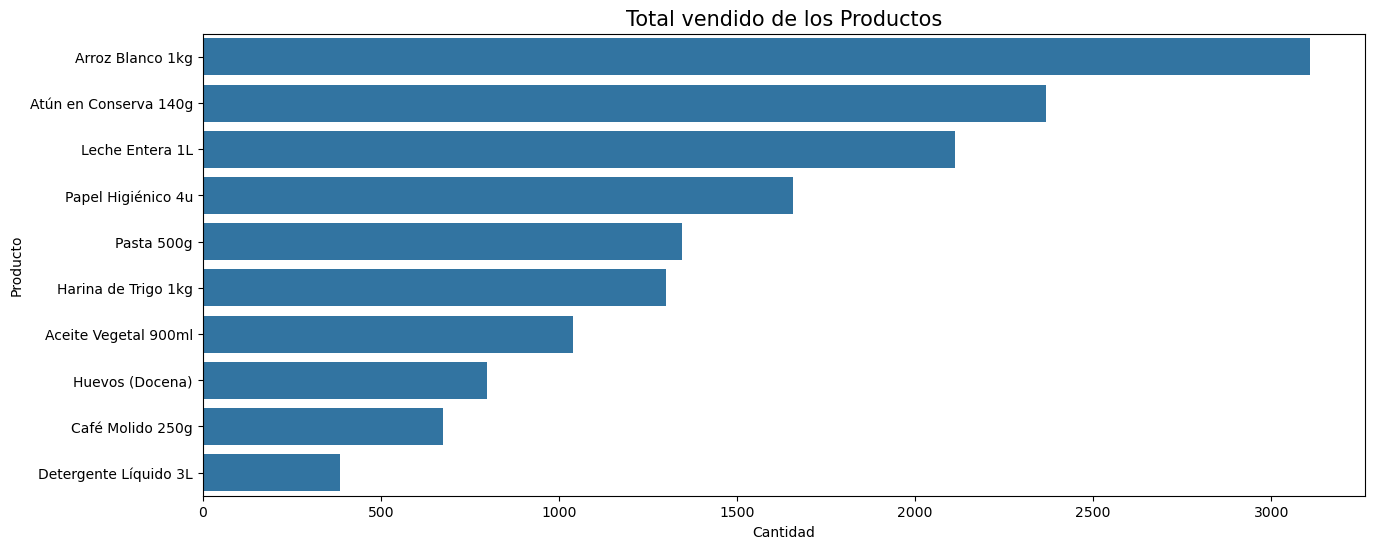

In [7]:
ventas  = df.groupby('nombre')['cantidad_vendida'].sum().sort_values(ascending=False)

plt.figure(figsize=(15,6))
sns.barplot(x=ventas.values, y=ventas.index)
plt.title('Total vendido de los Productos', fontsize=15)
plt.xlabel('Cantidad')
plt.ylabel('Producto')
plt.show()

C:\Users\ariel\AppData\Local\Temp\ipykernel_16112\2682711922.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promdia, x='dia_nombre', y='cantidad_vendida', palette='Blues_d')


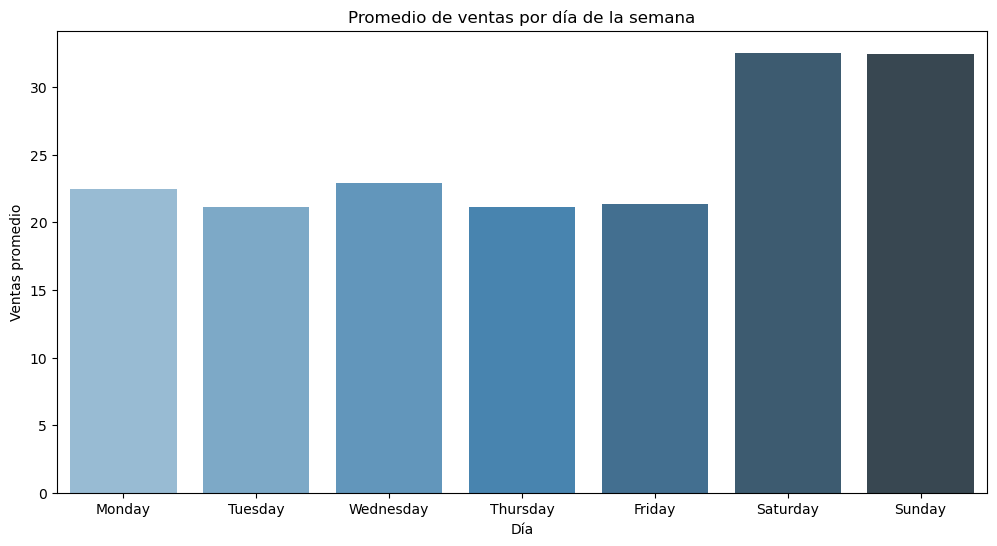

In [8]:
df['dia_nombre'] = df['fecha_venta'].dt.day_name()
df['dia_num'] = df['fecha_venta'].dt.weekday 

promdia = df.groupby(['dia_num', 'dia_nombre'])['cantidad_vendida'].mean().reset_index()
promdia = promdia.sort_values('dia_num')

plt.figure(figsize = (12,6))
sns.barplot(data=promdia, x='dia_nombre', y='cantidad_vendida', palette='Blues_d')
plt.title('Promedio de ventas por día de la semana')
plt.xlabel('Día')
plt.ylabel('Ventas promedio')
plt.show()

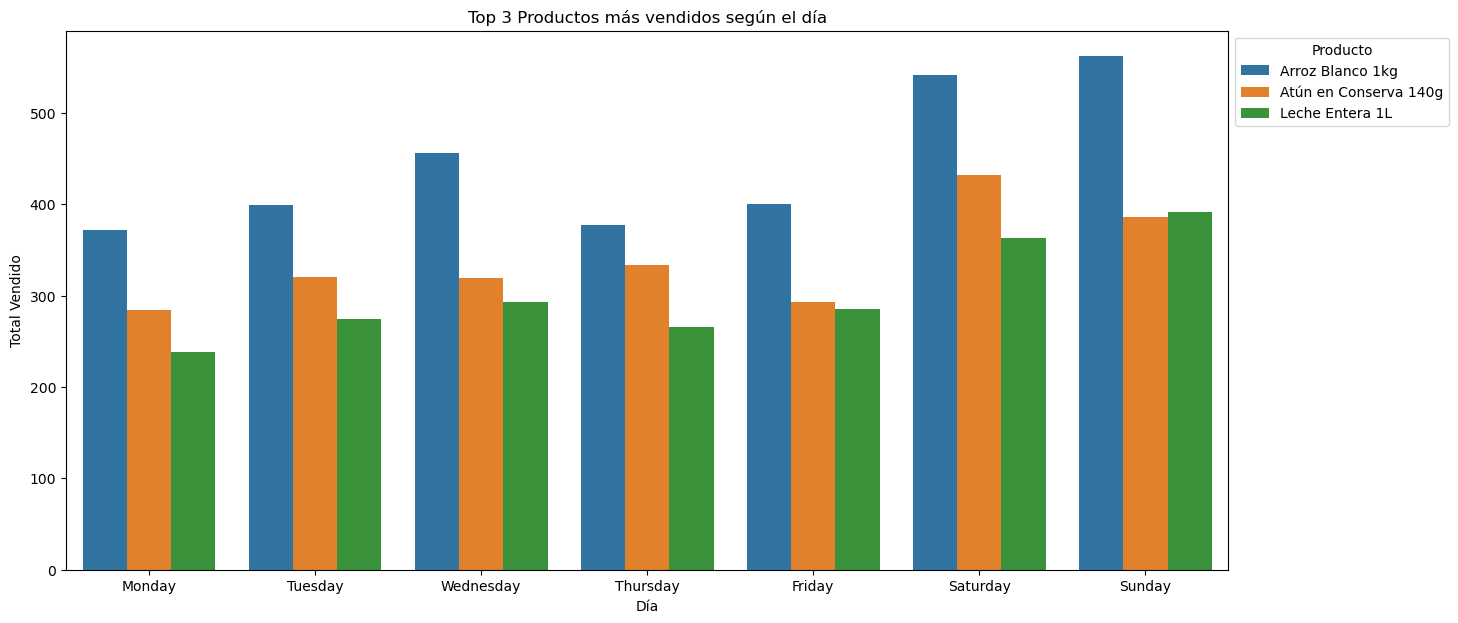

In [9]:
ventas_prod = df.groupby(['dia_nombre', 'dia_num', 'nombre'])['cantidad_vendida'].sum().reset_index()

top_por_dia = ventas_prod.sort_values(['dia_num', 'cantidad_vendida'], ascending=[True, False]).groupby('dia_nombre').head(3)

plt.figure(figsize = (15,7))
sns.barplot(data=top_por_dia, x='dia_nombre', y='cantidad_vendida', hue='nombre')
plt.title('Top 3 Productos más vendidos según el día')
plt.xlabel('Día')
plt.ylabel('Total Vendido')
plt.legend(title='Producto', bbox_to_anchor=(1, 1))
plt.show()

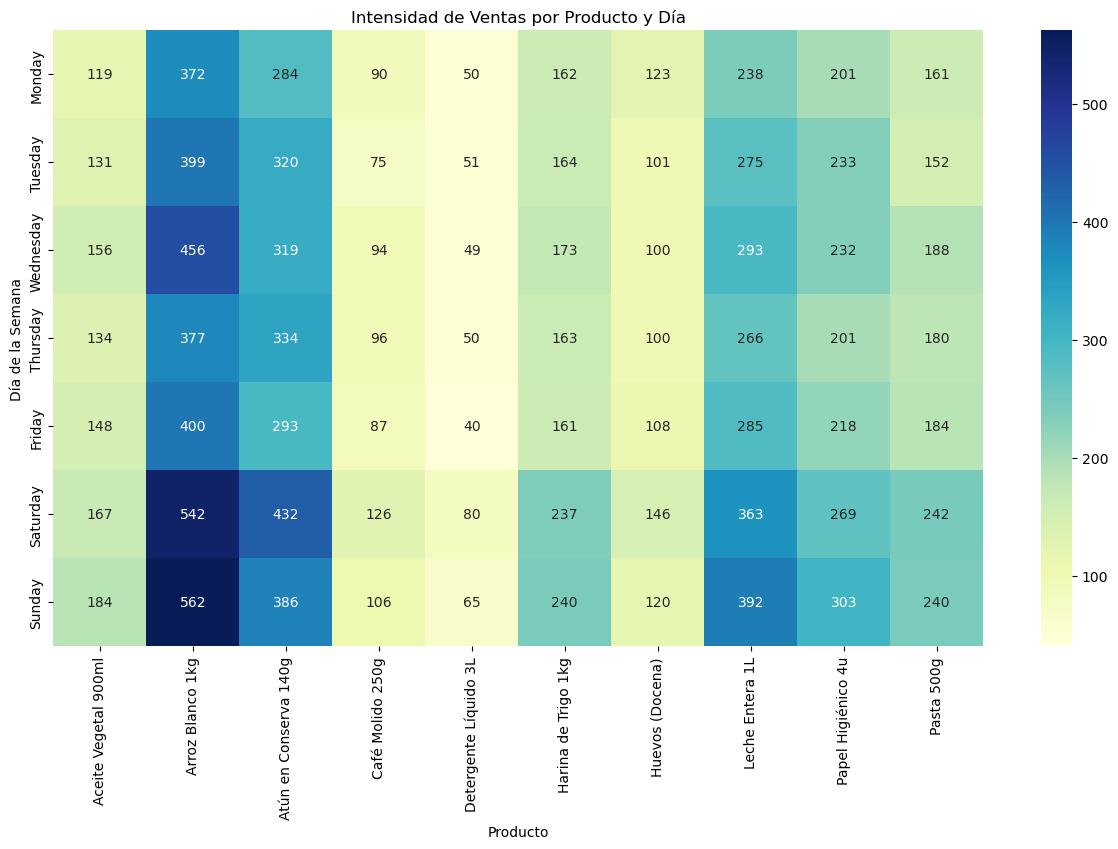

In [10]:
dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = df.pivot_table(index='dia_nombre', columns='nombre', values='cantidad_vendida', aggfunc='sum').reindex(dias_ordenados)

plt.figure(figsize = (15,8))
sns.heatmap(pivot, cmap='YlGnBu', annot=True, fmt=".0f")
plt.title('Intensidad de Ventas por Producto y Día')
plt.xlabel('Producto')
plt.ylabel('Día de la Semana')
plt.show()

<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Feature Engineering: Variables temporales</h2> </div>

In [11]:
df['dia_semana'] = df['fecha_venta'].dt.dayofweek
df['mes'] = df['fecha_venta'].dt.month
df['fin_de_semana'] = (df['dia_semana'] >= 5).astype(int)

df = df.sort_values(by=['product_id', 'fecha_venta'])
df['ventas_lag_1'] = df.groupby('product_id')['cantidad_vendida'].shift(1) #Venta hace 1 dia
df['ventas_lag_2'] = df.groupby('product_id')['cantidad_vendida'].shift(2) #Venta hace 2 dias

df['media_movil_7d'] = df.groupby('product_id')['cantidad_vendida'].rolling(window=7).mean().reset_index(0, drop=True) #Promedio de la semana
df = df.fillna(0)

df.head(10)

,product_id,nombre,fecha_venta,cantidad_vendida,stock_en_momento,dia_nombre,dia_num,dia_semana,mes,fin_de_semana,ventas_lag_1,ventas_lag_2,media_movil_7d
0,101,Leche Entera 1L,2024-03-05,26,500,Tuesday,1,1,3,0,0.0,0.0,0.000000
10,101,Leche Entera 1L,2024-03-06,32,474,Wednesday,2,2,3,0,26.0,0.0,0.000000
20,101,Leche Entera 1L,2024-03-07,30,442,Thursday,3,3,3,0,32.0,26.0,0.000000
30,101,Leche Entera 1L,2024-03-08,34,412,Friday,4,4,3,0,30.0,32.0,0.000000
40,101,Leche Entera 1L,2024-03-09,54,378,Saturday,5,5,3,1,34.0,30.0,0.000000
50,101,Leche Entera 1L,2024-03-10,40,324,Sunday,6,6,3,1,54.0,34.0,0.000000
60,101,Leche Entera 1L,2024-03-11,28,284,Monday,0,0,3,0,40.0,54.0,34.857143
70,101,Leche Entera 1L,2024-03-12,37,256,Tuesday,1,1,3,0,28.0,40.0,36.428571
80,101,Leche Entera 1L,2024-03-13,40,219,Wednesday,2,2,3,0,37.0,28.0,37.571429
90,101,Leche Entera 1L,2024-03-14,36,179,Thursday,3,3,3,0,40.0,37.0,38.428571




<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Normalización</h2> </div>

In [12]:
columnas = ['stock_en_momento', 'dia_semana', 'mes', 'fin_de_semana', 'ventas_lag_1', 'ventas_lag_2', 'media_movil_7d']
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Ventana </h2> </div>

In [13]:
fechas = df_sales['fecha_venta'].sort_values().unique()
fecha_split = fechas[int(len(fechas) * 0.7)]

df_train = df[df['fecha_venta'] <= fecha_split].copy()
df_test = df[df['fecha_venta'] > fecha_split].copy()

df_train[columnas] = scaler_X.fit_transform(df_train[columnas])
df_train['cantidad_vendida_scaled'] = scaler_y.fit_transform(df_train[['cantidad_vendida']])

df_test[columnas] = scaler_X.transform(df_test[columnas])
df_test['cantidad_vendida_scaled'] = scaler_y.transform(df_test[['cantidad_vendida']])

pasos = 7

def crear_secuencias(df_data):
    X_seq, y_seq = [], []
    for pid in df_data['product_id'].unique():
        datos = df_data[df_data['product_id'] == pid][columnas].values
        ventas = df_data[df_data['product_id'] == pid]['cantidad_vendida_scaled'].values
        if len(datos) > pasos:
            for i in range(len(datos) - pasos):
                X_seq.append(datos[i : i + pasos])
                y_seq.append(ventas[i + pasos])
                
    return np.array(X_seq), np.array(y_seq)

X_train, y_train = crear_secuencias(df_train)
X_test, y_test = crear_secuencias(df_test)



<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Modelo RNN</h2> </div>

In [14]:
modelo = Sequential([
    LSTM(32, activation='relu', input_shape=(pasos, len(columnas))),
    Dense(16, activation='relu'),
    Dense(1)
])

modelo.compile(optimizer='adam', loss='mse')

e_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

modelo.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), 
           callbacks=[e_stop], batch_size=16, verbose=0)

predic = scaler_y.inverse_transform(modelo.predict(X_test, verbose=0))
ytest_r = scaler_y.inverse_transform(y_test.reshape(-1, 1))

rmse = np.sqrt(mean_squared_error(ytest_r, predic))
r2 = r2_score(ytest_r, predic)
mape = mean_absolute_percentage_error(ytest_r, predic)
mae = mean_absolute_error(ytest_r, predic)

print("--- EVALUACIÓN FINAL DEL MODELO ---")
print(f"Precisión del Modelo (R² Score): {r2*100:.2f}%")
print(f"Error Promedio en Unidades (MAE): {mae:.2f} unidades")
print(f"Error Porcentual (MAPE): {mape*100:.2f}%")
print(f"RMSE (Error Cuadrático): {rmse:.2f}")
print(f"Modelo entrenado. RMSE en test: {rmse:.2f}")




--- EVALUACIÓN FINAL DEL MODELO ---
Precisión del Modelo (R² Score): 81.93%
Error Promedio en Unidades (MAE): 4.57 unidades
Error Porcentual (MAPE): 23.88%
RMSE (Error Cuadrático): 5.81
Modelo entrenado. RMSE en test: 5.81




<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Funciones de Prediccion</h2> </div>

In [15]:
def predecir_demanda(product_id, fecha_str):
    fecha_objetivo = pd.to_datetime(fecha_str)
    
    historial = df[(df['product_id'] == product_id) & 
                         (df['fecha_venta'] < fecha_objetivo)].sort_values('fecha_venta')
    
    if len(historial) < pasos:
        return 0
    
    ventana = historial.tail(pasos)[columnas]
    datos_escalados = scaler_X.transform(ventana)
    
    X_pred = datos_escalados.reshape(1, pasos, len(columnas))
    preds = modelo.predict(X_pred, verbose=0)
    
    pred_real = scaler_y.inverse_transform(preds)[0][0]
    return max(0, int(round(pred_real)))

def predecir_demanda_lista(lista_productos, fecha_str):
    return {pid: predecir_demanda(pid, fecha_str) for pid in lista_productos}

In [19]:
print(f"\nPredicción individual (Prod 101): {predecir_demanda(101, '2024-05-02')} unidades")
print(predecir_demanda_lista([101, 102, 103], '2024-05-02'))


Predicción individual (Prod 101): 32 unidades
{101: 32, 102: 43, 103: 13}




<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Convertir Modelo</h2> </div>

In [ ]:
spec = (tf.TensorSpec((None, pasos, len(columnas)), tf.float32, name="input"),)

modelo_onnx, _ = tf2onnx.convert.from_keras(modelo, input_signature=spec)

with open("modelo_ventas.onnx", "wb") as f:
    f.write(modelo_onnx.SerializeToString())
    

<div id="RNN" style="color:#37475a; border-bottom: 4px solid #4E853C; width: 100%; margin-bottom: 15px; padding-bottom: 2px"><h2>Conclusiones</h2> </div>

El modelo de Red Neuronal Recurrente implementado logró una predicción precisa tras optimizar el preprocesamiento de los datos, alcanzando valores entre 14 y 46 unidades para los productos analizados. El éxito del modelo radicó en la implementación de un escalado independiente para la variable objetivo y la inclusión de características temporales (como el mes y fin de semana), lo que permitió a la red capturar la estacionalidad de las ventas y reducir significativamente el error cuadrático medio. Finalmente, se demostró que el uso de una arquitectura SimpleRNN con una etapa de desescalada adecuada es una herramienta robusta para la gestión de inventarios, logrando una convergencia estable y una inferencia lógica basada en el historial secuencial de los productos.